# AI-Powered Resume Screening & Job Matching System using NLP
## Objective

The goal of this project is to automate the initial resume screening process by comparing candidate skills with job requirements. Using Natural Language Processing (NLP) techniques, resumes are cleaned, analyzed, and matched against internship descriptions to identify the most suitable candidates.

## Project Workflow

1. Data Loading
2. Exploratory Data Analysis
3. Text Preprocessing
4. Skill Extraction
5. Resume-Job Matching
6. Candidate Ranking
7. Multi-Role Analysis
8. Conclusions and Insights


## Datasets Used

1. Resume Dataset (2484 resumes across multiple domains,Raw resume text data)
2. Job Dataset (15 internship descriptions across ML, DS, NLP, Web Development, Cyber Security, and Software Development)


##### NLP Techniques Used

1. Text Cleaning
2. Lowercasing
3. Special Character Removal
4. Whitespace Normalization
5. Skill Extraction using Keyword Matching


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Acquisition and Understanding

In [184]:
resume=pd.read_csv("/content/drive/MyDrive/Resume screening project/Resume.csv")

In [185]:
resume.head(10)

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
5,11592605,HR GENERALIST Summary Dedic...,"<div class=""fontsize fontface vmargins hmargin...",HR
6,25824789,HR MANAGER Summary HUMAN RES...,"<div class=""fontsize fontface vmargins hmargin...",HR
7,15375009,HR MANAGER Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",HR
8,11847784,HR SPECIALIST Summary Posses...,"<div class=""fontsize fontface vmargins hmargin...",HR
9,32896934,HR CLERK Summary Translates ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [186]:
resume.tail(10)

,ID,Resume_str,Resume_html,Category
2474,28020046,PRODUCTION EXCELLENCE SPECIALIST ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2475,25625173,SENIOR LEAD TECHNOLOGIST EDITOR ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2476,29534737,PRODUCTION SUPERVISOR / VALUE STREAM ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2477,17655479,PEST CONTROL TECH Summary ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2478,12043694,ADVANCED LEVEL WHEELED VEHICLE MECHAN...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2483,37473139,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [187]:
resume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [188]:
resume.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [189]:
resume.shape

(2484, 4)

In [190]:
resume.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [191]:
resume.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [192]:
#Checking categories(Types)
resume["Category"].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


EDA and Visualizations

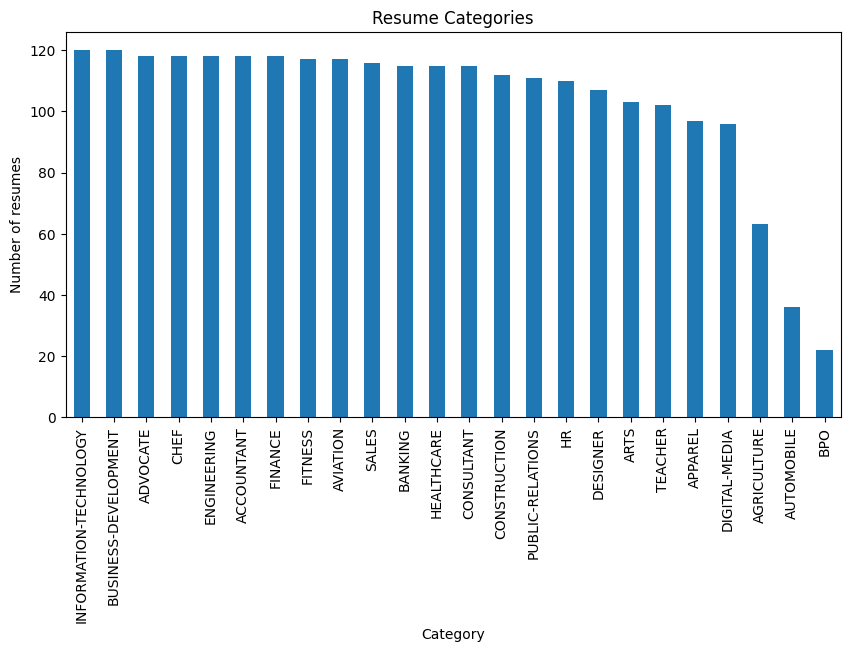

In [193]:
#Bar chart for categories
resume["Category"].value_counts().plot(kind="bar",figsize=(10,5))
plt.title("Resume Categories")
plt.ylabel("Number of resumes")
plt.show()

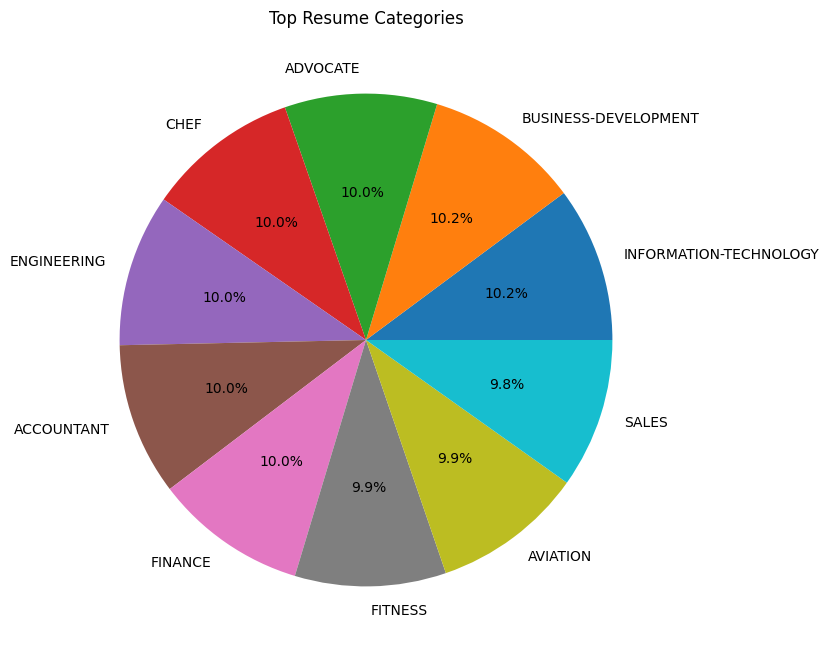

In [194]:
#Pie chart for top 10 categories
resume["Category"].value_counts().head(10).plot(kind="pie",autopct="%1.1f%%",figsize=(8,8))
plt.title("Top Resume Categories")
plt.ylabel("")
plt.show()

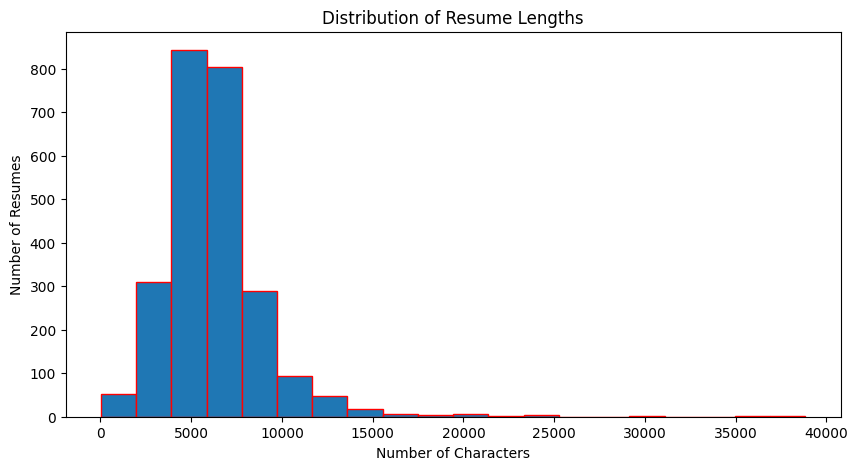

In [195]:
#Histogram for resume length
resume["Resume_Length"] = resume["Resume_str"].apply(len)

plt.figure(figsize=(10,5))
plt.hist(resume["Resume_Length"],bins=20,edgecolor="red")
plt.title("Distribution of Resume Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Resumes")
plt.show()

The majority of resumes contain 4,000 to 8,000 characters, indicating that most candidates provide a moderate amount of information regarding their skills, education, and experience. The distribution is positively skewed, with a small number of resumes being significantly longer than the average.We can assume longer length resumes may be of people with more work experience and certifications.

In [196]:
print(resume["Resume_str"][0][:500])


         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


In [197]:
jobs=pd.read_csv("/content/drive/MyDrive/Resume screening project/jobs.csv")
jobs

,Unnamed: 0,Job_Title,Skills,Description
0,1,Machine Learning Intern,"Artificial intelligence,Data Analytics, Data S...",Assist in developing and implementing machine ...
1,2,Machine Learning Intern,"Python, Data Analytics, Data Science, NLP, Dee...",Develop and implement machine learning algorit...
2,3,Machine Learning Intern,"Python, Data Analytics, Machine Learning, R Pr...",Collaborate with the team to develop and imple...
3,4,Data Science Intern,"Data Analysis, Statistics, Sentiment Analysis,...",Analyze trader performance across different ma...
4,5,Data Science Intern,"Machine Learning, Data Science, NLP, Deep Lear...",Collaborate with the team to analyze and inter...
5,6,Data Science Intern,"Data Analysis, Predictive Modeling, Data Visua...","Assist in collecting, processing, and analyzin..."
6,7,NLP Intern,"Natural Language Processing, Chatbots, Convers...",Assist in improving chatbot and conversational...
7,8,Web Development Intern,"PHP, MySQL, HTML, CSS, JavaScript, jQuery, Wor...","Develop and maintain websites using PHP, MySQL..."
8,9,Web Development Intern,"HTML, Web Development, Website Maintenance, We...",Assist in creating and maintaining websites us...
9,10,Web Development Intern,"PHP, MySQL, HTML, CSS, JavaScript, jQuery, Wor...",Collaborate with the development team to desig...


In [198]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   15 non-null     int64 
 1   Job_Title    15 non-null     object
 2   Skills       15 non-null     object
 3   Description  15 non-null     object
dtypes: int64(1), object(3)
memory usage: 612.0+ bytes


In [199]:
jobs.shape

(15, 4)

In [200]:
jobs.describe()

,Unnamed: 0
count,15.000000
mean,8.000000
std,4.472136
min,1.000000
25%,4.500000
50%,8.000000
75%,11.500000
max,15.000000


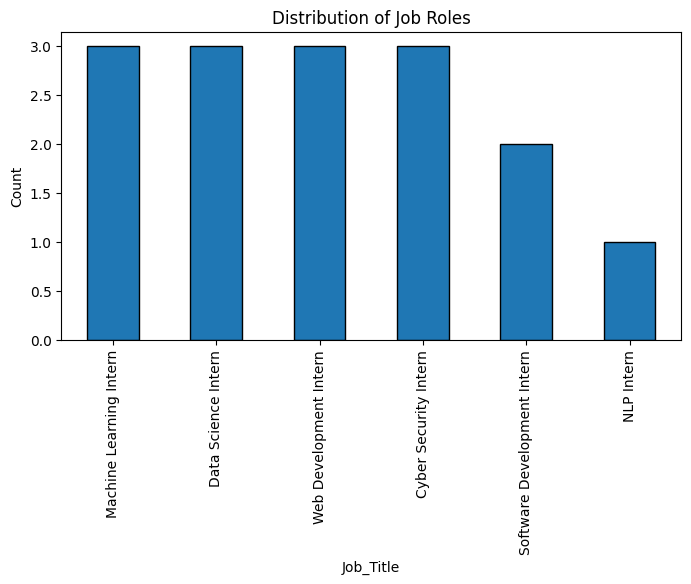

In [201]:
jobs["Job_Title"].value_counts().plot(kind="bar",figsize=(8,4),edgecolor="black")
plt.title("Distribution of Job Roles")
plt.ylabel("Count")
plt.show()

In [202]:
#Extracting skills
all_skills = []
for skills in jobs["Skills"]:
    skill_list = skills.split(",")
    for skill in skill_list:
        all_skills.append(skill.strip())

In [203]:
#Count skills
skill_count = {}
for skill in all_skills:
    if skill in skill_count:
        skill_count[skill] += 1
    else:
        skill_count[skill] = 1
print(skill_count)

{'Artificial intelligence': 1, 'Data Analytics': 3, 'Data Science': 5, 'Machine Learning': 6, 'Python': 6, 'R Programming': 2, 'NLP': 3, 'Deep Learning': 3, 'Artificial Intelligence': 2, 'Data Analysis': 3, 'Statistics': 2, 'Sentiment Analysis': 1, 'Data Visualization': 3, 'Dashboarding': 1, 'Performance Analysis': 1, 'Financial Analytics': 1, 'Reporting': 2, 'Predictive Modeling': 2, 'Research': 2, 'Natural Language Processing': 1, 'Chatbots': 1, 'Conversational AI': 1, 'Tokenization': 1, 'Text Normalization': 1, 'Documentation': 1, 'PHP': 2, 'MySQL': 2, 'HTML': 3, 'CSS': 2, 'JavaScript': 2, 'jQuery': 2, 'WordPress': 2, 'Bootstrap': 2, 'Node.js': 2, 'Testing': 1, 'Debugging': 4, 'Web Development': 1, 'Website Maintenance': 1, 'Website Testing': 1, 'Troubleshooting': 1, 'Performance Optimization': 1, 'Content Management': 1, 'UI/UX': 1, 'Collaboration': 1, 'React': 1, 'Responsive Design': 1, 'Computer Networking': 1, 'Linux': 1, 'Ethical Hacking': 1, 'VAPT': 1, 'Web Application Securit

In [204]:
skills_df = pd.DataFrame(skill_count.items(),columns=["Skill","Count"])
skills_df

,Skill,Count
0,Artificial intelligence,1
1,Data Analytics,3
2,Data Science,5
3,Machine Learning,6
4,Python,6
...,...,...
76,REST APIs,1
77,Firebase,1
78,UI/UX Design,1
79,Backend Integration,1


In [205]:
#Sorting(highest to lowest)
skills_df = skills_df.sort_values(by="Count",ascending=False)
skills_df.head(10)

,Skill,Count
4,Python,6
3,Machine Learning,6
2,Data Science,5
35,Debugging,4
6,NLP,3
12,Data Visualization,3
7,Deep Learning,3
9,Data Analysis,3
1,Data Analytics,3
52,Vulnerability Assessment,3


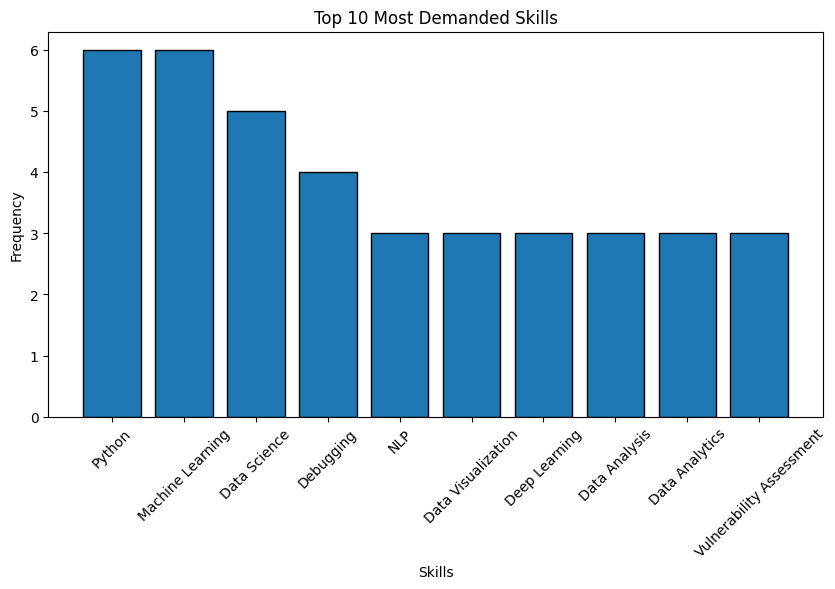

In [206]:
top10 = skills_df.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10["Skill"],top10["Count"],edgecolor="black")
plt.xticks(rotation=45)
plt.title("Top 10 Skills in Job Descriptions")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.show()

Python, Machine Learning, Data Analysis, and NLP appear among the most frequently requested skills across job descriptions. This indicates a strong demand for AI, data-driven decision making, and programming skills in current internship opportunities.

# Text Preprocessing

In [207]:
#Creating cleaning function
import re
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text) #Removing unwanted special characters nd digits
    text = re.sub(r'\s+', ' ', text)        #Replacing whitespaces with single space
    return text

In [208]:
#Clean resume dataset
resume["Clean_Resume"] = resume["Resume_str"].apply(clean_text)
resume[["Resume_str","Clean_Resume"]].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admin...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versat...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in ...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dy...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depa...


In [209]:
#Cleaning jobs dataset
jobs["Clean_Description"] = jobs["Description"].apply(clean_text)
jobs.head()

,Unnamed: 0,Job_Title,Skills,Description,Clean_Description
0,1,Machine Learning Intern,"Artificial intelligence,Data Analytics, Data S...",Assist in developing and implementing machine ...,assist in developing and implementing machine ...
1,2,Machine Learning Intern,"Python, Data Analytics, Data Science, NLP, Dee...",Develop and implement machine learning algorit...,develop and implement machine learning algorit...
2,3,Machine Learning Intern,"Python, Data Analytics, Machine Learning, R Pr...",Collaborate with the team to develop and imple...,collaborate with the team to develop and imple...
3,4,Data Science Intern,"Data Analysis, Statistics, Sentiment Analysis,...",Analyze trader performance across different ma...,analyze trader performance across different ma...
4,5,Data Science Intern,"Machine Learning, Data Science, NLP, Deep Lear...",Collaborate with the team to analyze and inter...,collaborate with the team to analyze and inter...


In [210]:
print("BEFORE")   #Comparing before and after cleaning datasets
print(resume["Resume_str"][0][:500])
print("\n")
print("AFTER")
print(resume["Clean_Resume"][0][:500])

BEFORE
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


AFTER
 hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomp

In [211]:
#All skills(Unique)
skills_list = [
"python",
"java",
"kotlin",
"javascript",
"php",
"r programming",
"machine learning",
"deep learning",
"artificial intelligence",
"nlp",
"data science",
"data analytics",
"html",
"css",
"bootstrap",
"jquery",
"wordpress",
"react",
"node.js",
"mysql",
"sql",
"ms sql server",
"android",
"xml",
"firebase",
"ethical hacking",
"vapt",
"web application security",
"network security",
"penetration testing",
"vulnerability assessment",
"security monitoring",
"incident response",
"security auditing",
"data analysis",
"predictive modeling",
"data visualization",
"chatgpt",
"github copilot",
"ai-assisted development",
"apis",
"rest api",
"backend development",
"frontend development",
"debugging",
"scrum",
"agile"]

In [212]:
#Testing it on 1st resume
sample_resume = resume["Clean_Resume"][0]
for skill in skills_list:
    if skill in sample_resume:
        print(skill)

data analysis


In [213]:
#Skill extraction
def extract_skills(text):
    found_skills = []
    for skill in skills_list:
        if skill in text:
            found_skills.append(skill)
    return found_skills

In [214]:
resume["Extracted_Skills"] = resume["Clean_Resume"].apply(extract_skills)

print("Resume Category:")   #one example of extracted skills
print(resume["Category"][220])

print("\nExtracted Skills:")
print(resume["Extracted_Skills"][220])

Resume Category:
INFORMATION-TECHNOLOGY

Extracted Skills:
['php', 'html', 'data analysis']


The extracted skills are stored as a list and later used for resume-job matching. This converts unstructured resume text into structured information that can be analyzed and compared with job requirements.

In [215]:
#Tech related skill testing
resume[resume["Category"]=="INFORMATION-TECHNOLOGY"][["Category","Extracted_Skills"]].head()

,Category,Extracted_Skills
217,INFORMATION-TECHNOLOGY,[html]
218,INFORMATION-TECHNOLOGY,[]
219,INFORMATION-TECHNOLOGY,[]
220,INFORMATION-TECHNOLOGY,"[php, html, data analysis]"
221,INFORMATION-TECHNOLOGY,[data analysis]


In [216]:
print(resume["Resume_str"][218][:1500])

         INFORMATION TECHNOLOGY SPECIALIST	GS11             Experience     07/2004   to   Current     Information Technology Specialist	GS11    Company Name   －   City  ,   State      Information Technology Specialist; Supervison; Project Management; Circuit Management; Licensed Electrician; Alarm management; Alarm Technician; Training; Supply; Quality Assurance Kevin L.  Trostle, DSN 266-4800, COMM.  865) 336-4800
Manage the assigned IT/communications environment with privileged access at the network level for the Wing, Geographically Separated Units (GSU), and Tenants.  Plan, coordinate, install, and continuously analyze system design, hardware and software.  Develop, recommend, and install solutions and upgrades to ensure availability, integrity, efficiency, and reliability of all components of the assigned system.  Ensure all performed work is captured in the Remedy ticketing system.  Manage Telecommunications and NIPR networks for the Wing, GSU's, and tenant units.  Continually pl

In [217]:
resume["Skill_Count"] = resume["Extracted_Skills"].apply(len)
resume["Skill_Count"].value_counts()

,count
Skill_Count,
0,1891
1,335
2,122
3,35
5,20
4,20
6,17
8,11
9,9


In [218]:
resume["Skill_Count"].describe()

,Skill_Count
count,2484.000000
mean,0.550725
std,1.508815
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,16.000000


Observation:
Out of 2484 resumes, 1891 resumes did not contain any of the technical skills extracted from the job descriptions. This is expected because the resume dataset contains multiple domains such as HR, Banking, Healthcare, Arts, and Education, while the collected job descriptions primarily focus on technical roles like Machine Learning, Data Science, Web Development, Cyber Security, and Android Development.

The median skill count is 0, indicating that more than half of the resumes have no direct overlap with the collected technical skills. However, some resumes contain up to 16 matching skills, making them strong candidates for technical positions.

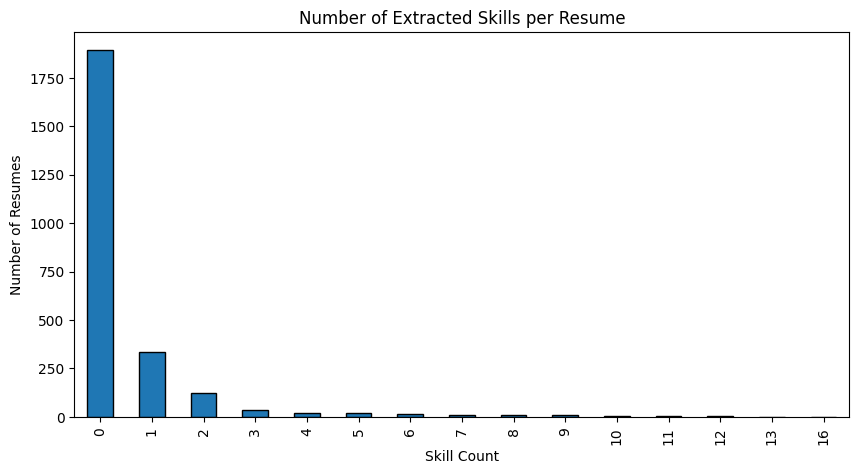

In [229]:
plt.figure(figsize=(10,5))
resume["Skill_Count"].value_counts().sort_index().plot(kind="bar",edgecolor="black")
plt.title("Number of Extracted Skills per Resume")
plt.xlabel("Skill Count")
plt.ylabel("Number of Resumes")
plt.show()

## Resume Matching for Machine Learning Internship[0]

The following analysis evaluates resume-job matching using the skills required for the selected Machine Learning internship role. Match scores are calculated based on the percentage of required skills present in each resume.

In [220]:
job_skills = jobs.loc[0, "Skills"]
job_skills = job_skills.lower().split(",")
print(job_skills)

['artificial intelligence', 'data analytics', ' data science', 'machine learning', 'python', 'r programming']


In [221]:
#Function to calculated number of skill matches
def calculate_match(resume_skills):
    common = []
    for skill in resume_skills:
        if skill in job_skills:
            common.append(skill)
    score=len(common)/len(job_skills)*100
    return score

In [222]:
resume["Match_Score"] = resume["Extracted_Skills"].apply(calculate_match)

In [223]:
resume[["Category","Extracted_Skills","Match_Score"]].head(10)

,Category,Extracted_Skills,Match_Score
0,HR,[data analysis],0.0
1,HR,[],0.0
2,HR,[],0.0
3,HR,[],0.0
4,HR,[],0.0
5,HR,[],0.0
6,HR,[],0.0
7,HR,[],0.0
8,HR,[],0.0
9,HR,[],0.0


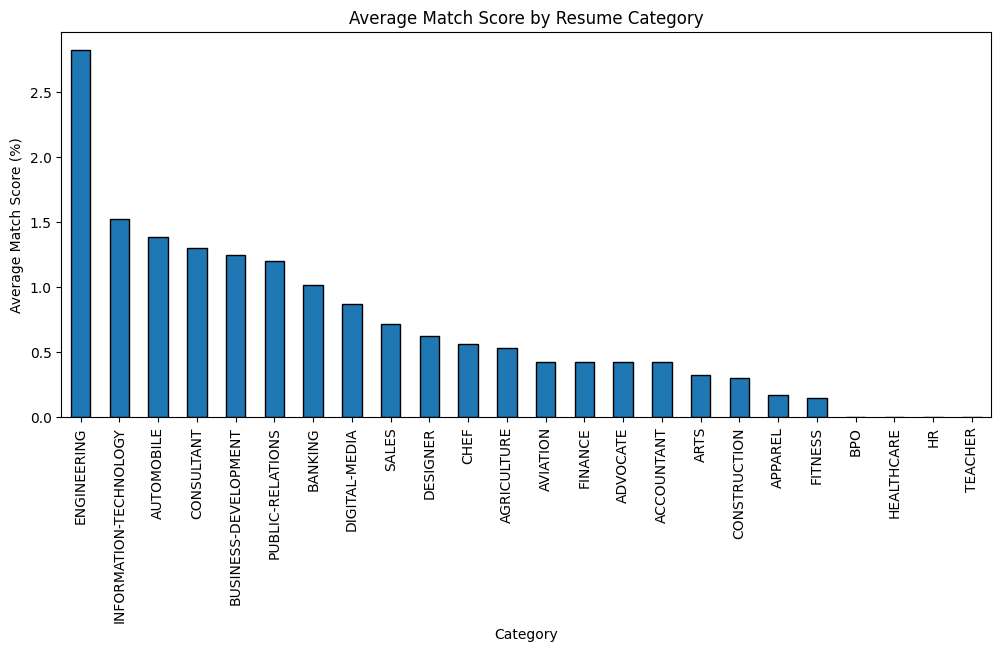

In [226]:
category_scores = resume.groupby("Category")["Match_Score"].mean()
category_scores = category_scores.sort_values(ascending=False)
plt.figure(figsize=(12,5))
category_scores.plot(kind="bar",edgecolor="black")
plt.title("Average Match Score by Resume Category")
plt.xlabel("Category")
plt.ylabel("Average Match Score (%)")
plt.show()

Observation:
The graph shows the average resume-job match score for each resume category against the selected Machine Learning internship. Engineering and Information Technology resumes achieved the highest average scores because they contain more relevant technical skills such as Python, Machine Learning, Data Analytics, Artificial Intelligence, and R Programming. Categories such as HR, Healthcare, and Teaching showed very low scores due to limited overlap with the required technical skills.

In [224]:
top_matches = resume.sort_values(by="Match_Score",ascending=False)

In [225]:
top_matches[["Category","Extracted_Skills","Match_Score"]].head(10)

,Category,Extracted_Skills,Match_Score
2120,PUBLIC-RELATIONS,"[machine learning, artificial intelligence, da...",50.000000
1762,ENGINEERING,"[python, machine learning, html, sql, data ana...",33.333333
2153,BANKING,"[python, machine learning, sql]",33.333333
662,BUSINESS-DEVELOPMENT,"[python, java, data analytics, sql]",33.333333
333,INFORMATION-TECHNOLOGY,"[python, r programming, html, network security]",33.333333
1040,SALES,"[machine learning, data analytics, data analysis]",33.333333
1348,AUTOMOBILE,"[python, java, machine learning, sql, data ana...",33.333333
1717,ENGINEERING,"[python, machine learning, sql]",33.333333
1218,CONSULTANT,"[python, java, javascript, machine learning, d...",33.333333
2093,PUBLIC-RELATIONS,[data analytics],16.666667


Observation:
The highest matching resume achieved a score of 50%, indicating that it contained 3/6 required skills for the selected Machine Learning internship. Most high ranking resumes had skills such as Python, Machine Learning, Artificial Intelligence, and Data Analytics. The matching process focuses on skill overlap rather than the resume category, allowing candidates from different professional backgrounds to be identified if they possess relevant technical skills.

In [227]:
results = []
for i in jobs.index:
    job_skills = jobs.loc[i,"Skills"]
    job_skills = job_skills.lower().split(",")
    resume["Match_Score"] = resume["Extracted_Skills"].apply(calculate_match)

    category_scores = resume.groupby("Category")["Match_Score"].mean()

    best_category = category_scores.idxmax()

    best_score = category_scores.max()

    results.append([i,jobs.loc[i,"Job_Title"],best_category,round(best_score,2)])

In [228]:
summary_table = pd.DataFrame(results,columns=["Job_Row","Job_Title","Best_Resume_Category","Average_Match_Score"])
summary_table.sort_values(by="Average_Match_Score",ascending=False)
summary_table

,Job_Row,Job_Title,Best_Resume_Category,Average_Match_Score
0,0,Machine Learning Intern,ENGINEERING,2.82
1,1,Machine Learning Intern,ENGINEERING,1.33
2,2,Machine Learning Intern,ENGINEERING,1.17
3,3,Data Science Intern,AUTOMOBILE,2.08
4,4,Data Science Intern,ENGINEERING,0.47
5,5,Data Science Intern,AUTOMOBILE,2.08
6,6,NLP Intern,ACCOUNTANT,0.00
7,7,Web Development Intern,INFORMATION-TECHNOLOGY,0.91
8,8,Web Development Intern,DIGITAL-MEDIA,2.78
9,9,Web Development Intern,INFORMATION-TECHNOLOGY,0.83


Information Technology and Engineering resumes consistently achieved higher average match scores across multiple internship roles, indicating stronger alignment with technical job requirements.

#Final Conclusion
This project successfully demonstrates how Natural Language Processing can be applied to automate resume screening and candidate-job matching.

##Key Findings:

- Python, Machine Learning, Data Analytics, and NLP were among the most demanded skills.
- Engineering and Information Technology resumes achieved the highest match scores for technical roles.
- Resume-job matching can significantly reduce manual screening effort by identifying relevant candidates automatically.